In [1]:
import pandas as pd
data=pd.read_parquet('TrainData/Train.parquet')

In [2]:

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4504473 entries, 0 to 4504472
Data columns (total 19 columns):
 #   Column             Dtype  
---  ------             -----  
 0   user_session       str    
 1   user_id            int64  
 2   day_of_week        int8   
 3   hour_of_day        int8   
 4   total_views        uint32 
 5   total_carts        uint32 
 6   total_removes      uint32 
 7   session_duration   int64  
 8   avg_price          float64
 9   max_price          float64
 10  unique_products    uint32 
 11  unique_brands      uint32 
 12  R_Score            int64  
 13  F_Score            int64  
 14  M_Score            int64  
 15  RFM_Total_Score    int64  
 16  is_purchased       int64  
 17  is_single_brand    int64  
 18  top_brand_encoded  float64
dtypes: float64(3), int64(8), int8(2), str(1), uint32(5)
memory usage: 661.6 MB


Kích thước dữ liệu gốc trong biến 'data': 4,504,473 dòng
Dữ liệu quá lớn! Đang trích xuất ngẫu nhiên 10% để vẽ biểu đồ cho mượt...
Kích thước dữ liệu dùng để vẽ: 450,447 dòng

--- Đang vẽ Hành vi và Giá cả ---


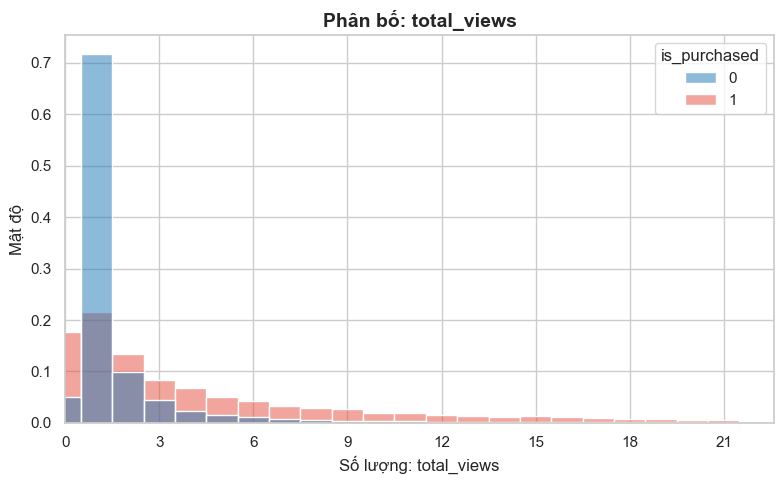

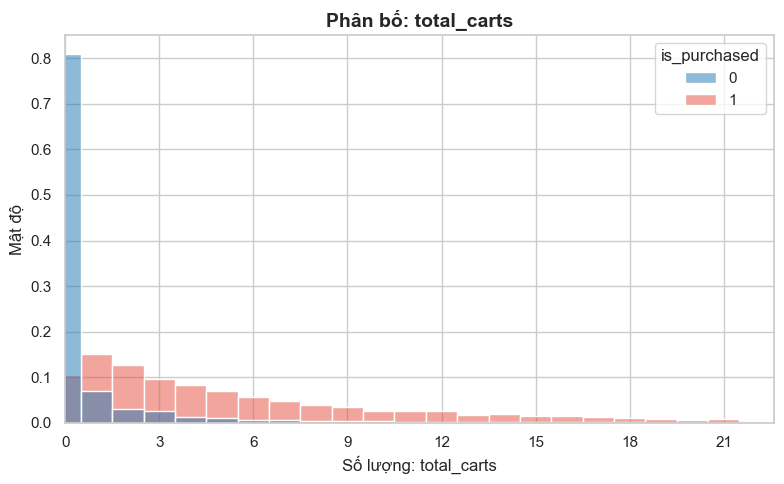

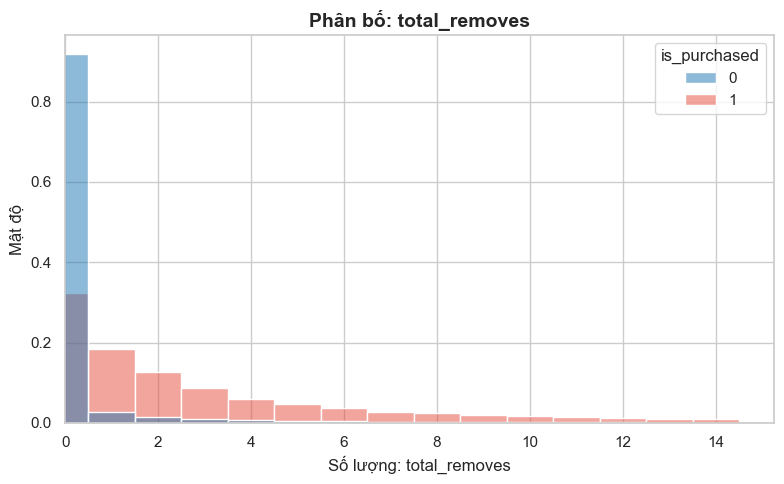

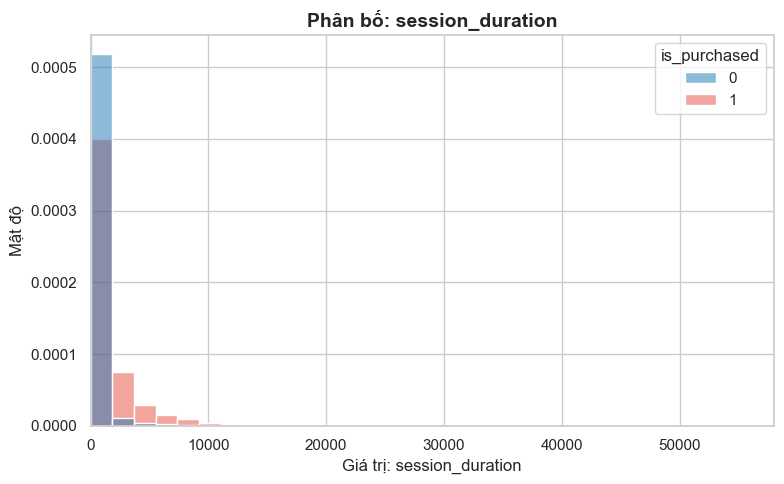

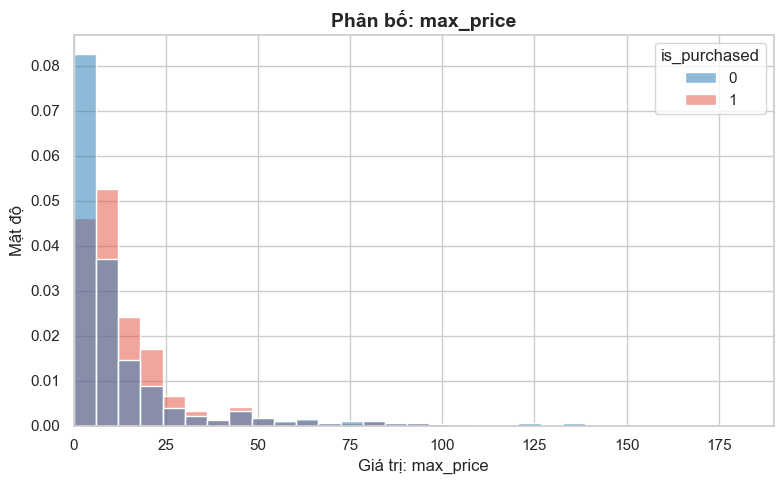

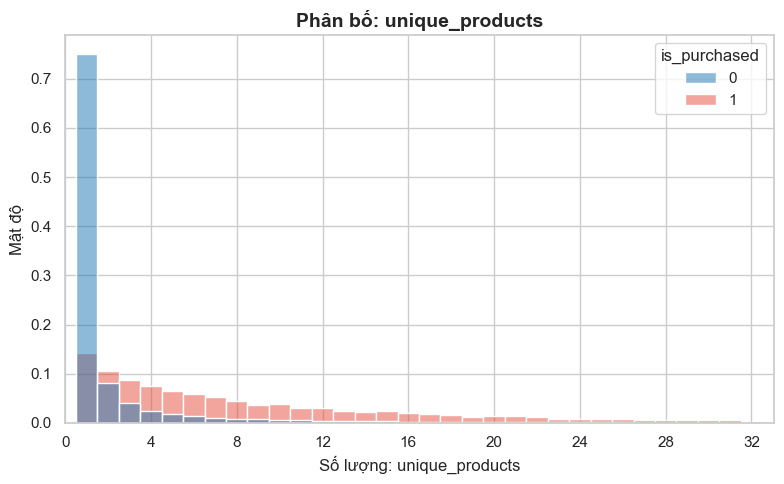

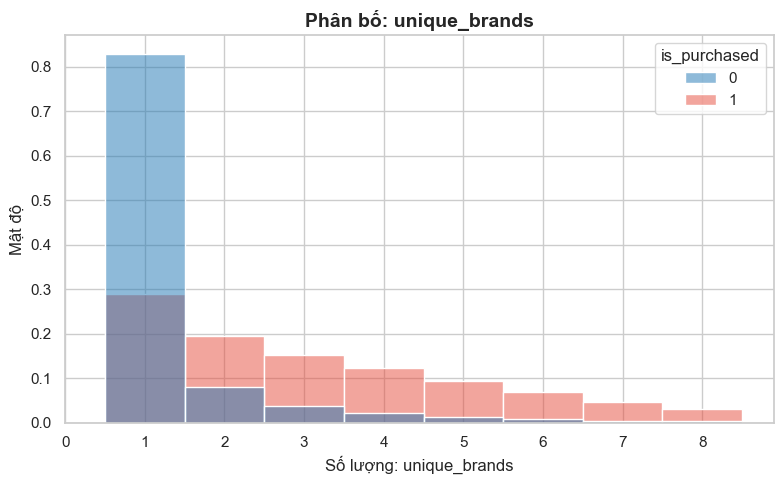

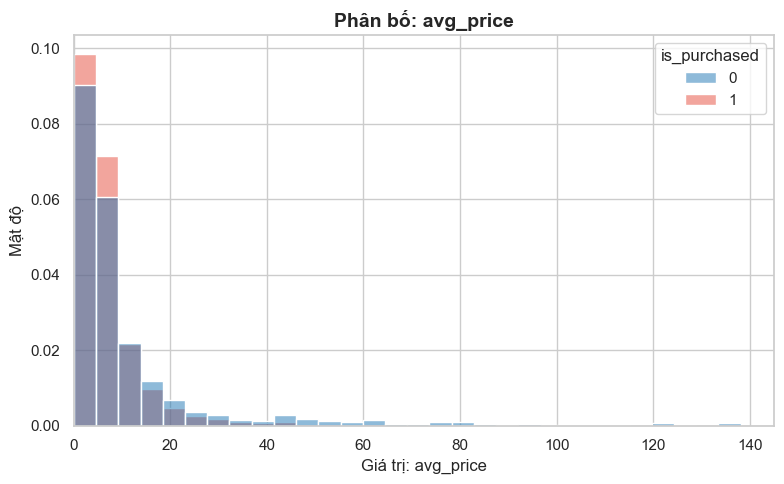


--- Đang vẽ Phân bố Điểm RFM ---


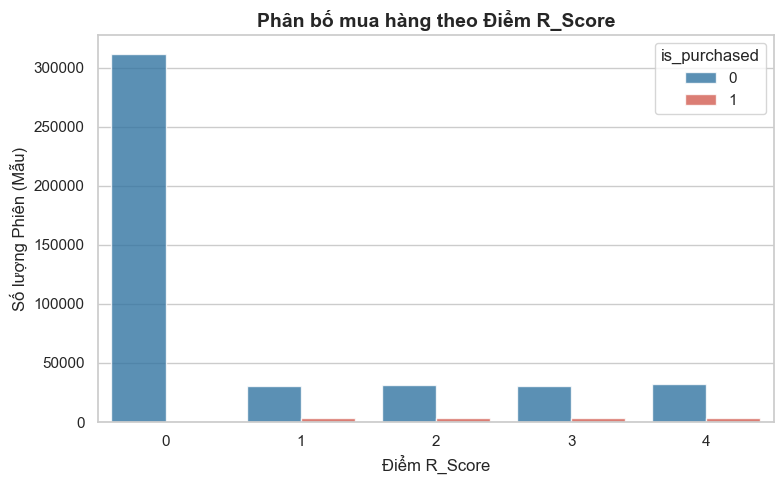

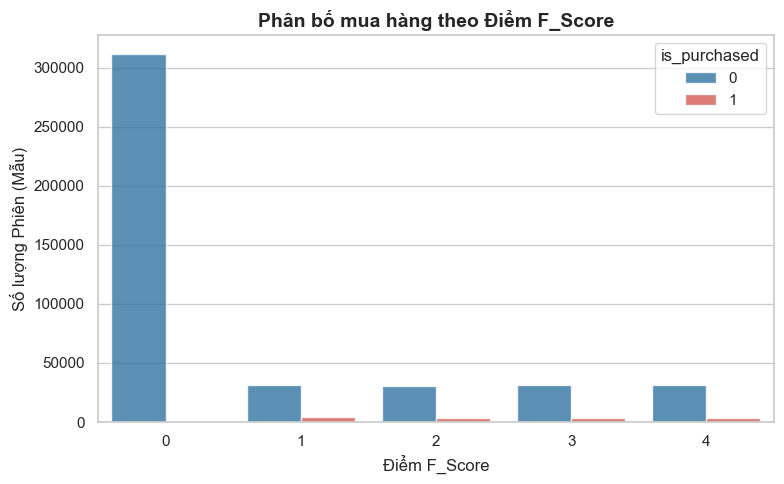

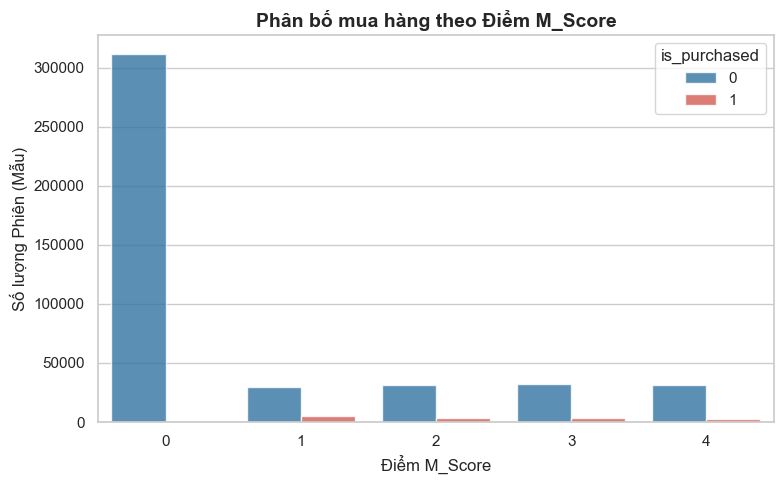

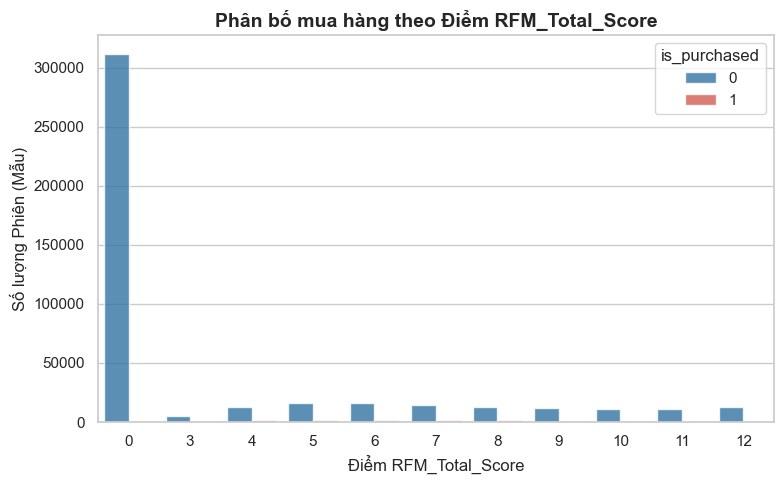


--- Đang vẽ Phân bố Thời gian ---


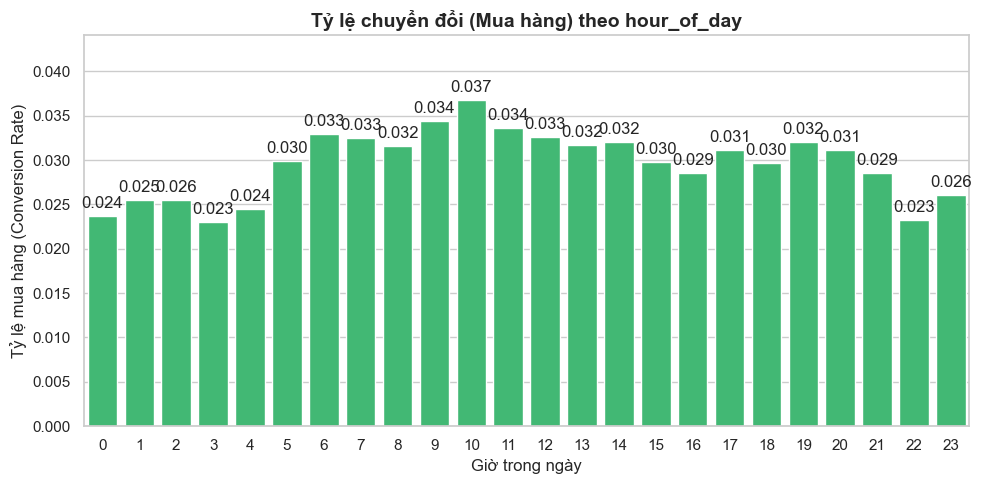

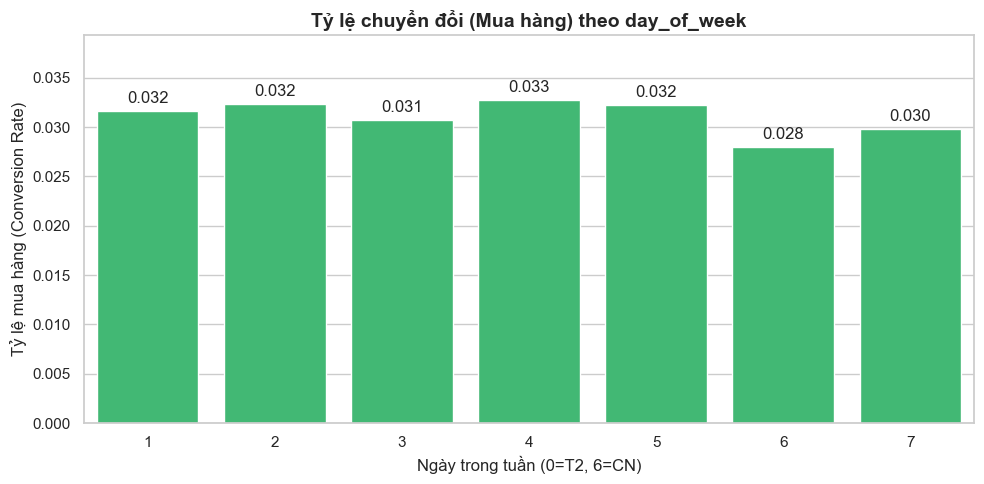


--- Đang vẽ Phân bố Top 15 Thương hiệu ---


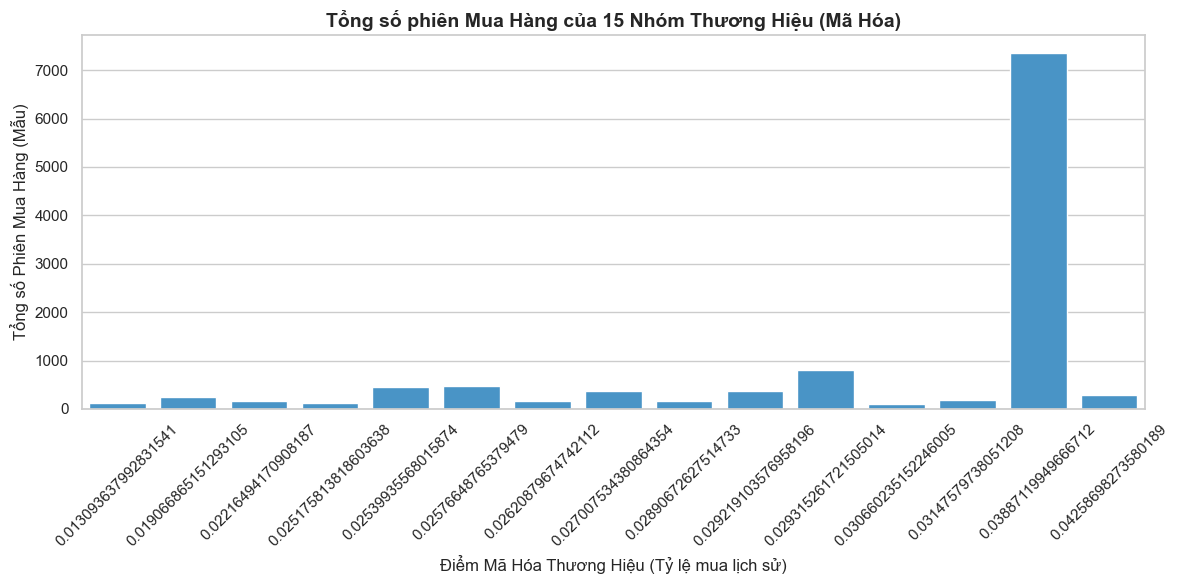


✅ Hoàn thành xuất toàn bộ biểu đồ siêu mượt!


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
import gc
import warnings
warnings.filterwarnings('ignore')

# ====================================================================
# LẤY MẪU (SAMPLING) ĐỂ VẼ BIỂU ĐỒ KHÔNG BỊ TRÀN RAM
# ====================================================================
print(f"Kích thước dữ liệu gốc trong biến 'data': {data.shape[0]:,} dòng")

# Tạo một tập dữ liệu nhỏ (data_viz) chỉ để vẽ biểu đồ
if data.shape[0] > 500000:
    print("Dữ liệu quá lớn! Đang trích xuất ngẫu nhiên 10% để vẽ biểu đồ cho mượt...")
    data_viz = data.sample(frac=0.1, random_state=42)
else:
    data_viz = data.copy()

print(f"Kích thước dữ liệu dùng để vẽ: {data_viz.shape[0]:,} dòng")

sns.set_theme(style="whitegrid")
palette_colors = ['#1f77b4', '#e74c3c'] 

# ====================================================================
# PHẦN 1: CÁC BIẾN HÀNH VI VÀ GIÁ CẢ (Tách riêng từng hình)
# ====================================================================
features_to_plot = [
    'total_views', 'total_carts', 'total_removes', 
    'session_duration', 'max_price', 'unique_products', 
    'unique_brands', 'avg_price'
]
int_features = ['total_views', 'total_carts', 'total_removes', 'unique_products', 'unique_brands']

print("\n--- Đang vẽ Hành vi và Giá cả ---")
for col in features_to_plot:
    plt.figure(figsize=(8, 5))
    
    # Tính toán quantile trên tập dữ liệu vẽ (data_viz)
    q_limit = float(data_viz[col].quantile(0.99))
    plot_data = data_viz.query(f"{col} <= {q_limit}") if q_limit > 0 else data_viz
    
    is_integer_feature = col in int_features
    
    sns.histplot(
        data=plot_data,          
        x=col, 
        hue='is_purchased', 
        stat='density',      
        common_norm=False,   
        palette=palette_colors,
        alpha=0.5,           
        edgecolor='white',
        discrete=is_integer_feature, 
        bins=None if is_integer_feature else 30
    )
    
    plt.xlim(left=0)
    if is_integer_feature:
        plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
        
    plt.title(f'Phân bố: {col}', fontsize=14, fontweight='bold')
    plt.xlabel(f'Số lượng: {col}' if is_integer_feature else f'Giá trị: {col}')
    plt.ylabel('Mật độ')
    plt.tight_layout()
    plt.show()
    gc.collect() # Dọn rác bộ nhớ


# ====================================================================
# PHẦN 2: CÁC BIẾN ĐIỂM RFM
# ====================================================================
rfm_features = ['R_Score', 'F_Score', 'M_Score', 'RFM_Total_Score']

print("\n--- Đang vẽ Phân bố Điểm RFM ---")
for col in rfm_features:
    plt.figure(figsize=(8, 5))
    
    sns.countplot(
        data=data_viz, 
        x=col, 
        hue='is_purchased',
        palette=palette_colors,
        alpha=0.8
    )
    
    plt.title(f'Phân bố mua hàng theo Điểm {col}', fontsize=14, fontweight='bold')
    plt.xlabel(f'Điểm {col}')
    plt.ylabel('Số lượng Phiên (Mẫu)')
    plt.legend(title='is_purchased')
    plt.tight_layout()
    plt.show()
    gc.collect()


# ====================================================================
# PHẦN 3: PHÂN BỐ THỜI GIAN
# ====================================================================
time_features = ['hour_of_day', 'day_of_week']

print("\n--- Đang vẽ Phân bố Thời gian ---")
for col in time_features:
    plt.figure(figsize=(10, 5))
    
    time_grouped = data_viz.groupby(col)['is_purchased'].mean().reset_index()
    ax = sns.barplot(data=time_grouped, x=col, y='is_purchased', color='#2ecc71')
    
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.3f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

    plt.title(f'Tỷ lệ chuyển đổi (Mua hàng) theo {col}', fontsize=14, fontweight='bold')
    plt.xlabel('Giờ trong ngày' if col == 'hour_of_day' else 'Ngày trong tuần (0=T2, 6=CN)')
    plt.ylabel('Tỷ lệ mua hàng (Conversion Rate)')
    plt.ylim(0, time_grouped['is_purchased'].max() * 1.2)
    plt.tight_layout()
    plt.show()
    gc.collect()


# ====================================================================
# PHẦN 4: TOP THƯƠNG HIỆU
# ====================================================================
print("\n--- Đang vẽ Phân bố Top 15 Thương hiệu ---")
try:
    plt.figure(figsize=(12, 6))
    top_brands = data_viz['top_brand_encoded'].value_counts().nlargest(15).index
    top_brands_data = data_viz[data_viz['top_brand_encoded'].isin(top_brands)]
    
    sns.barplot(
        data=top_brands_data, 
        x='top_brand_encoded', 
        y='is_purchased',
        estimator=sum, 
        errorbar=None,
        color='#3498db'
    )
    plt.title('Tổng số phiên Mua Hàng của 15 Nhóm Thương Hiệu (Mã Hóa)', fontsize=14, fontweight='bold')
    plt.xlabel('Điểm Mã Hóa Thương Hiệu (Tỷ lệ mua lịch sử)')
    plt.ylabel('Tổng số Phiên Mua Hàng (Mẫu)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
except Exception as e:
     print("Bỏ qua biểu đồ Brand do lỗi:", e)

# Dọn dẹp bản sao data_viz sau khi vẽ xong để trả lại RAM
del data_viz
gc.collect()
print("\n✅ Hoàn thành xuất toàn bộ biểu đồ siêu mượt!")

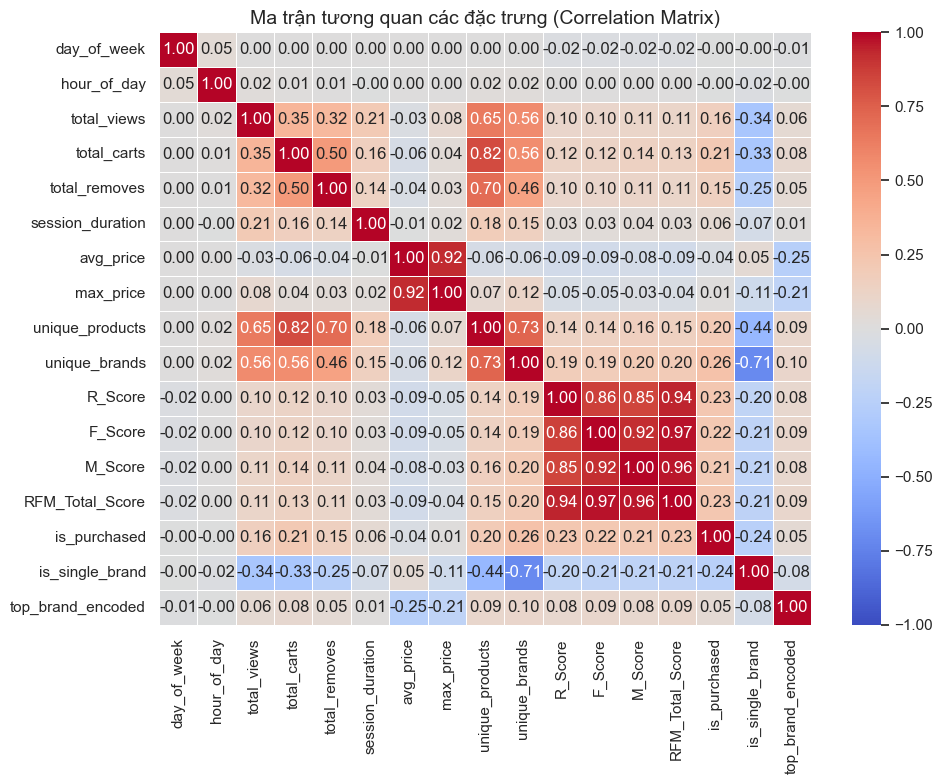

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chọn các cột dạng số (loại bỏ cột user_session)
# Bạn có thể dùng df.select_dtypes(include=['int64', 'float64'])
numeric_df = data.drop(columns=['user_session','user_id'])

# 2. Tính toán ma trận tương quan (mặc định là Pearson)
corr_matrix = numeric_df.corr()

# 3. Vẽ ma trận tương quan
plt.figure(figsize=(10, 8)) # Thiết lập kích thước khung hình

# Sử dụng seaborn heatmap để vẽ
sns.heatmap(corr_matrix, 
            annot=True,       # Hiển thị giá trị tương quan trên từng ô
            cmap='coolwarm',  # Chọn bảng màu (coolwarm hiển thị rõ âm/dương)
            fmt=".2f",        # Làm tròn 2 chữ số thập phân
            linewidths=0.5,   # Độ dày đường viền giữa các ô
            vmin=-1, vmax=1)  # Giới hạn thang màu từ -1 đến 1

# Thêm tiêu đề
plt.title('Ma trận tương quan các đặc trưng (Correlation Matrix)', fontsize=14)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

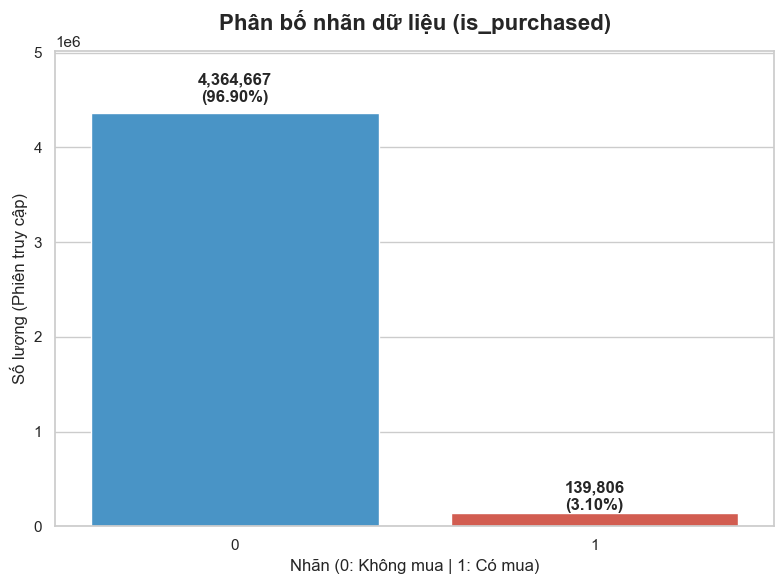

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Giả sử DataFrame của bạn đang có tên là 'data'
# data = pd.read_csv('du_lieu_cua_ban.csv')

# 1. Tính toán số lượng và tỷ lệ phần trăm
class_counts = data['is_purchased'].value_counts()
class_percentages = data['is_purchased'].value_counts(normalize=True) * 100

# 2. Thiết lập kích thước biểu đồ
plt.figure(figsize=(8, 6))

# 3. Vẽ biểu đồ cột bằng Seaborn
ax = sns.barplot(
    x=class_counts.index, 
    y=class_counts.values, 
    palette=['#3498db', '#e74c3c'] # Màu xanh cho 0, màu đỏ cho 1
)

# 4. Thêm tiêu đề và nhãn
plt.title('Phân bố nhãn dữ liệu (is_purchased)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Nhãn (0: Không mua | 1: Có mua)', fontsize=12)
plt.ylabel('Số lượng (Phiên truy cập)', fontsize=12)

# 5. Thêm chú thích (Số lượng & Phần trăm) trực tiếp lên từng cột
for i, count in enumerate(class_counts.values):
    # Tính phần trăm tương ứng
    percentage = class_percentages.values[i]
    
    # Hiển thị text trên đầu cột
    ax.text(
        i, count + (count * 0.02), # Vị trí Y (cao hơn đỉnh cột 1 chút)
        f"{count:,}\n({percentage:.2f}%)", # Nội dung: Số lượng \n (Phần trăm)
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

# 6. Điều chỉnh giới hạn trục Y để chữ không bị cắt
plt.ylim(0, class_counts.max() * 1.15)

# 7. Hiển thị
plt.tight_layout()
plt.show()

Kích thước dữ liệu gốc trong biến 'data': 4,504,473 dòng
Dữ liệu quá lớn. Đang trích xuất ngẫu nhiên 10% để vẽ biểu đồ...
Kích thước dữ liệu dùng để vẽ: 450,447 dòng

--- Đang vẽ khảo sát Mật độ phân bố đặc trưng theo Nhãn ---


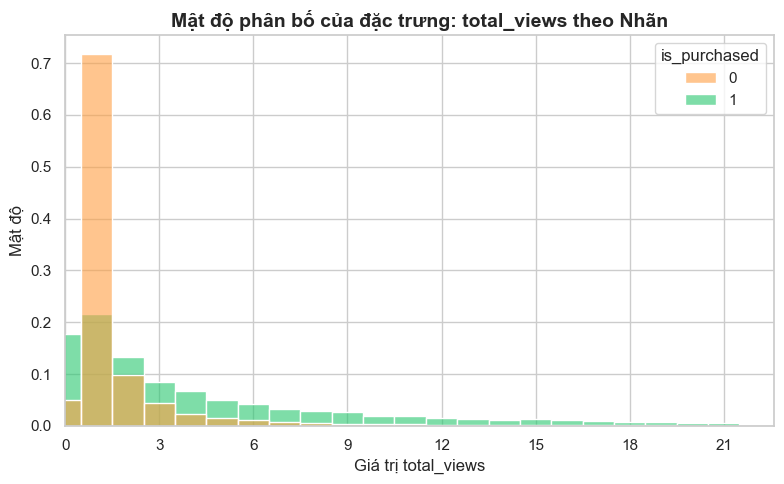

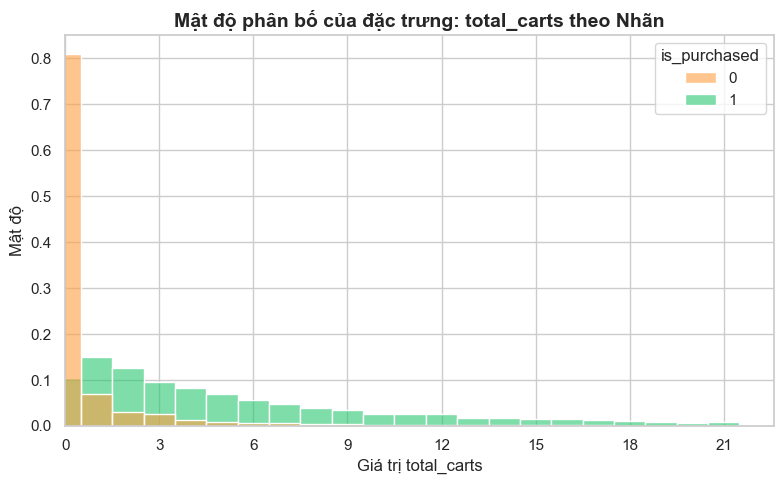

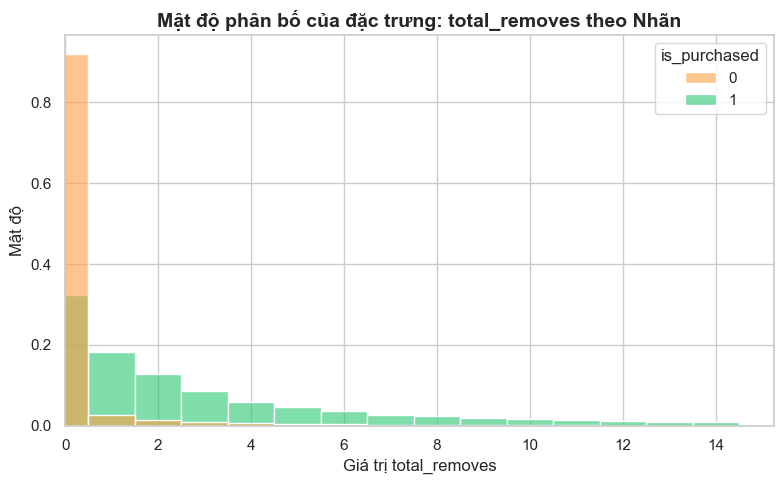

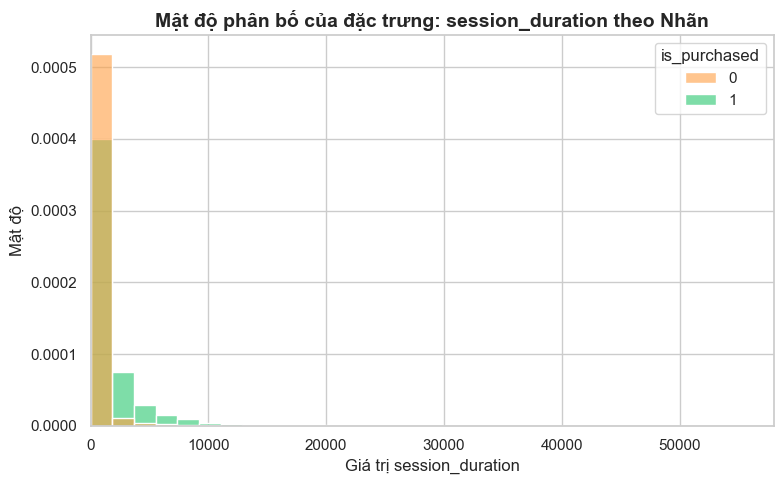

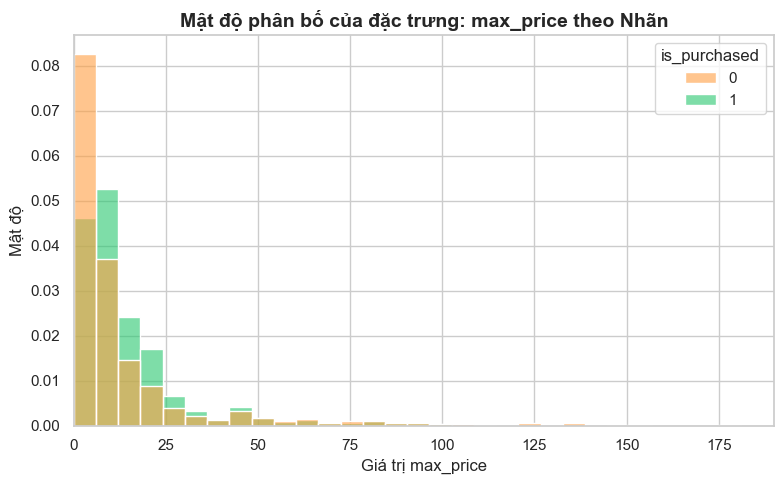

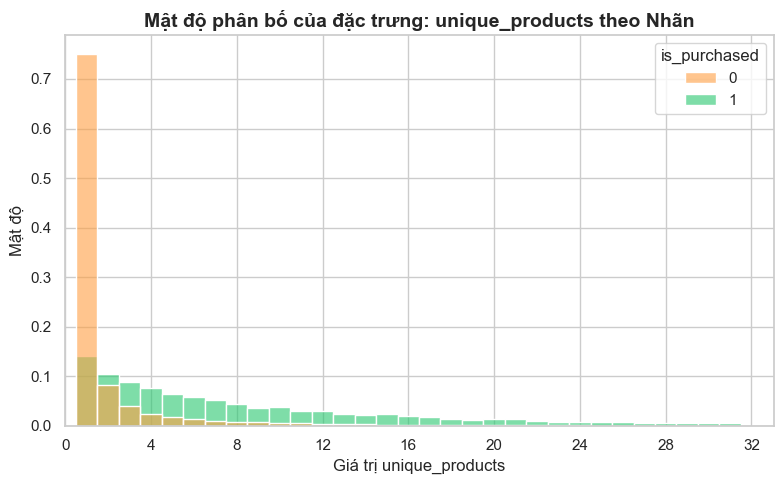

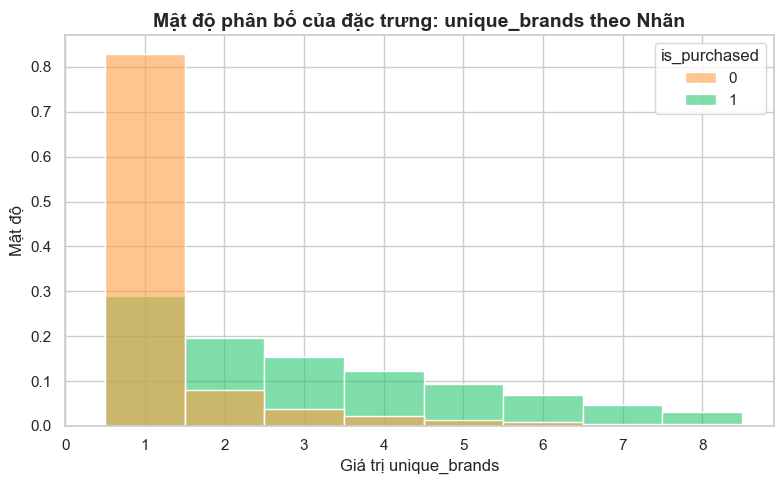

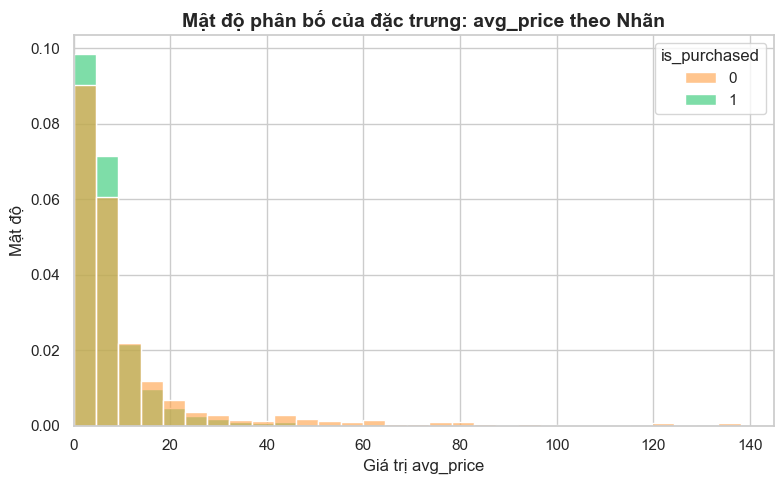


--- Đang vẽ Trung bình điểm RFM theo Nhãn ---


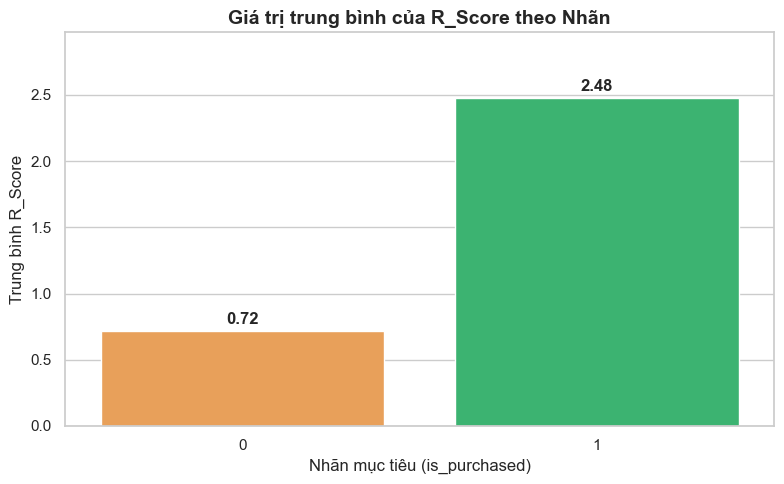

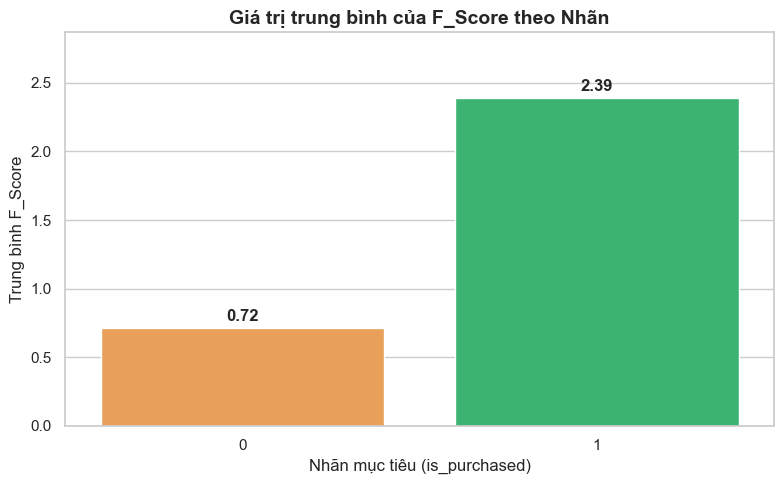

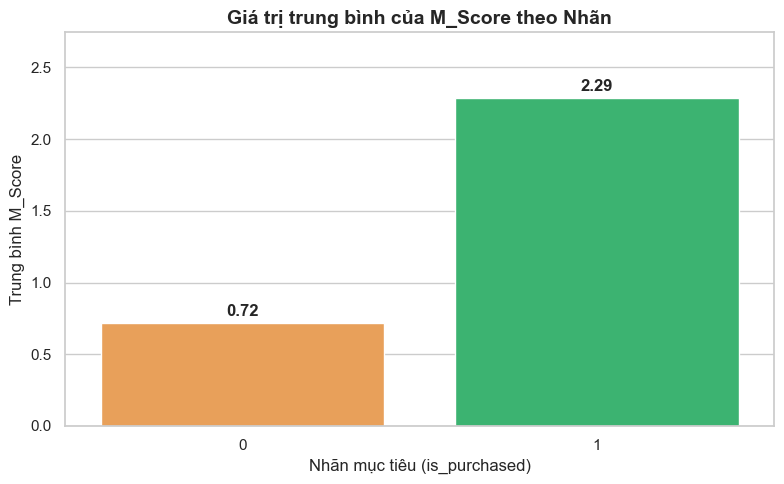

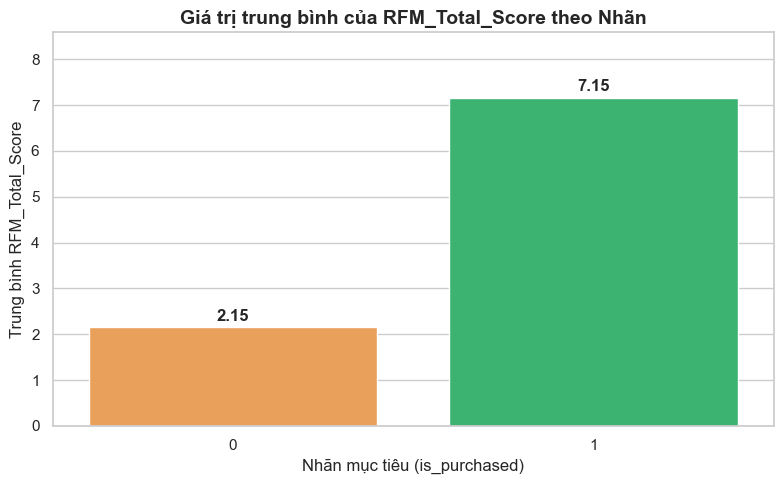


--- Đang vẽ Trung bình nhãn theo Thời gian ---


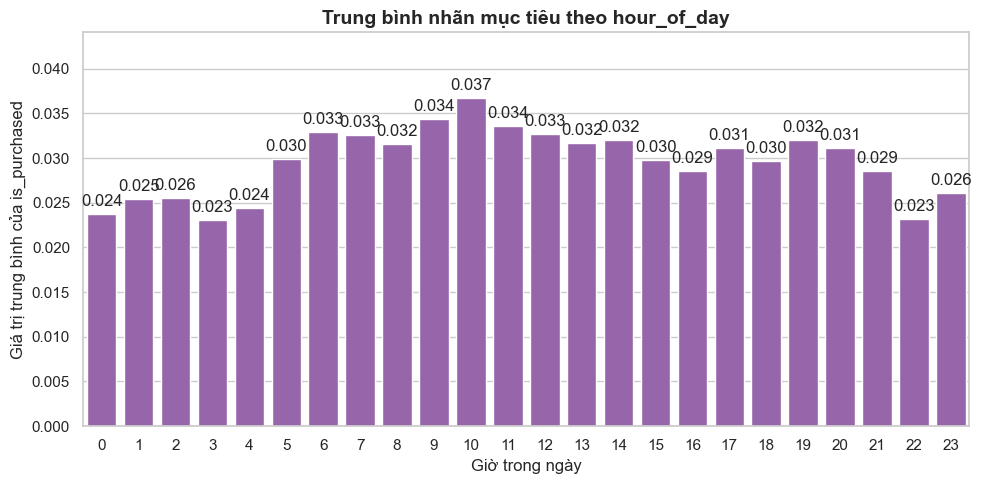

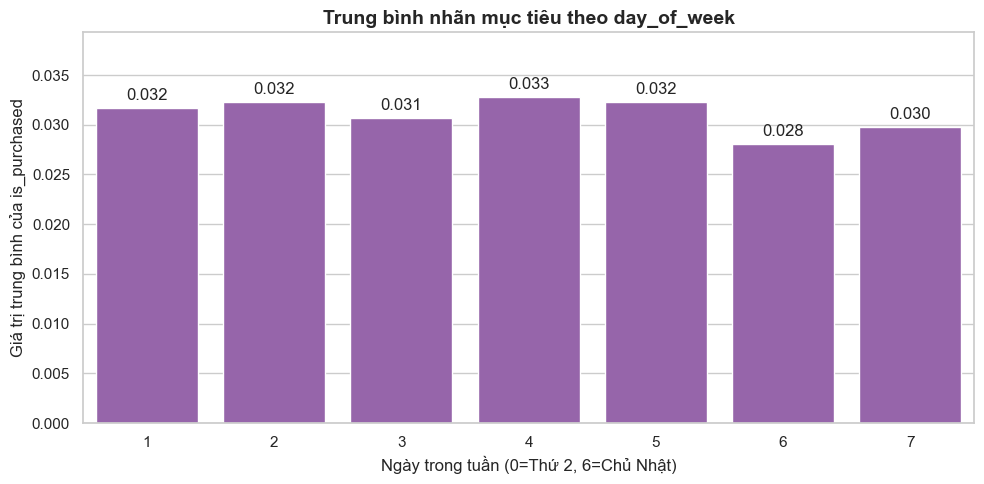


--- Đang vẽ Top 15 Nhóm Thương hiệu ---


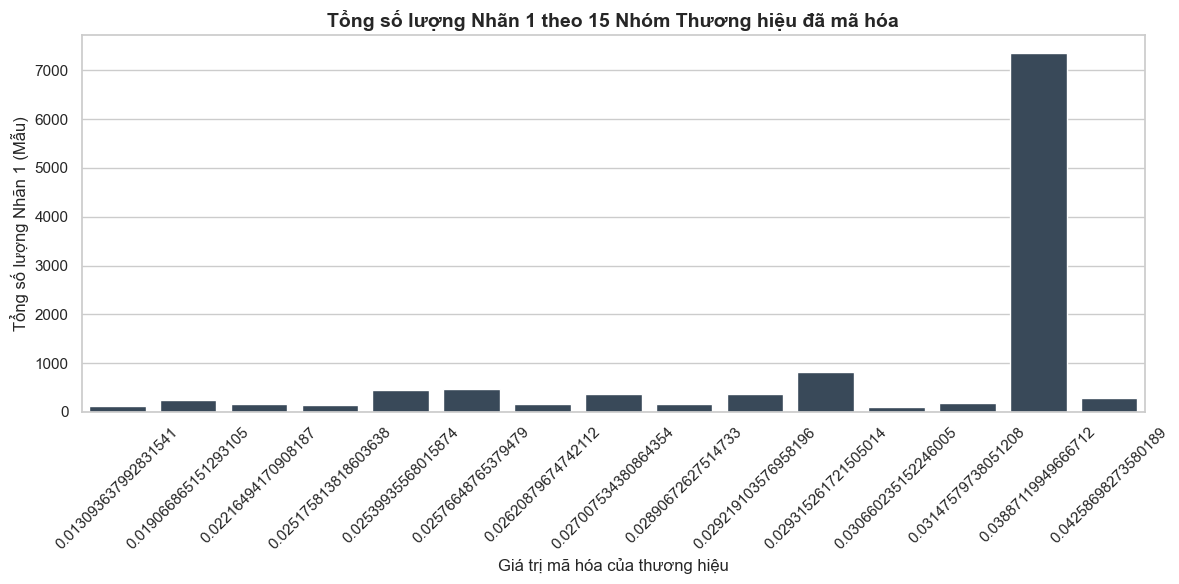


Hoàn thành xuất toàn bộ biểu đồ.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
import gc
import warnings
warnings.filterwarnings('ignore')

# Đảm bảo hiển thị tiếng Việt (nếu biểu đồ bị ô vuông, bạn có thể uncomment dòng dưới)
# plt.rcParams['font.family'] = 'Arial' 

# ====================================================================
# LẤY MẪU (SAMPLING) ĐỂ VẼ BIỂU ĐỒ KHÔNG BỊ TRÀN RAM
# ====================================================================
print(f"Kích thước dữ liệu gốc trong biến 'data': {data.shape[0]:,} dòng")

if data.shape[0] > 500000:
    print("Dữ liệu quá lớn. Đang trích xuất ngẫu nhiên 10% để vẽ biểu đồ...")
    data_viz = data.sample(frac=0.1, random_state=42)
else:
    data_viz = data.copy()

# ÉP KIỂU VỀ SỐ NGUYÊN ĐỂ TRÁNH LỖI PALETTE ('0', '1' -> 0, 1)
data_viz['is_purchased'] = data_viz['is_purchased'].astype(int)

print(f"Kích thước dữ liệu dùng để vẽ: {data_viz.shape[0]:,} dòng")

sns.set_theme(style="whitegrid")
# Đã đổi sang dải màu mới: Cam (0 - Không mua) và Xanh lá (1 - Có mua)
palette_labels = {0: '#FF9F43', 1: '#28C76F'}

# ====================================================================
# PHẦN 1: KHẢO SÁT MẬT ĐỘ PHÂN BỐ CỦA CÁC ĐẶC TRƯNG THEO NHÃN
# ====================================================================
features_to_plot = [
    'total_views', 'total_carts', 'total_removes', 
    'session_duration', 'max_price', 'unique_products', 
    'unique_brands', 'avg_price'
]
int_features = ['total_views', 'total_carts', 'total_removes', 'unique_products', 'unique_brands']

print("\n--- Đang vẽ khảo sát Mật độ phân bố đặc trưng theo Nhãn ---")
for col in features_to_plot:
    plt.figure(figsize=(8, 5))
    
    q_limit = float(data_viz[col].quantile(0.99))
    plot_data = data_viz.query(f"{col} <= {q_limit}") if q_limit > 0 else data_viz
    
    is_integer_feature = col in int_features
    
    sns.histplot(
        data=plot_data,          
        x=col, 
        hue='is_purchased',  
        stat='density',      
        common_norm=False,   
        palette=palette_labels,
        alpha=0.6,           
        edgecolor='white',
        discrete=is_integer_feature, 
        bins=None if is_integer_feature else 30
    )
    
    plt.xlim(left=0)
    if is_integer_feature:
        plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
        
    plt.title(f'Mật độ phân bố của đặc trưng: {col} theo Nhãn', fontsize=14, fontweight='bold')
    plt.xlabel(f'Giá trị {col}')
    plt.ylabel('Mật độ')
    plt.tight_layout()
    plt.show()
    gc.collect() 


# ====================================================================
# PHẦN 2: TRUNG BÌNH CÁC CHỈ SỐ RFM THEO TỪNG LOẠI NHÃN
# ====================================================================
rfm_features = ['R_Score', 'F_Score', 'M_Score', 'RFM_Total_Score']

print("\n--- Đang vẽ Trung bình điểm RFM theo Nhãn ---")
for col in rfm_features:
    plt.figure(figsize=(8, 5))
    
    mean_rfm = data_viz.groupby('is_purchased')[col].mean().reset_index()
    
    ax = sns.barplot(
        data=mean_rfm, 
        x='is_purchased', 
        y=col,
        hue='is_purchased', # Bổ sung hue để tương thích Seaborn mới
        palette=palette_labels,
        legend=False        # Ẩn chú thích vì trục x đã hiển thị nhãn
    )
    
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.2f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 8), 
                   textcoords = 'offset points',
                   fontweight='bold')
        
    plt.title(f'Giá trị trung bình của {col} theo Nhãn', fontsize=14, fontweight='bold')
    plt.xlabel('Nhãn mục tiêu (is_purchased)')
    plt.ylabel(f'Trung bình {col}')
    plt.ylim(0, mean_rfm[col].max() * 1.2)
    plt.tight_layout()
    plt.show()
    gc.collect()


# ====================================================================
# PHẦN 3: GIÁ TRỊ TRUNG BÌNH CỦA NHÃN THEO THỜI GIAN
# ====================================================================
time_features = ['hour_of_day', 'day_of_week']
color_time = '#9B59B6' # Đổi màu cho biểu đồ thời gian sang màu Tím hiện đại

print("\n--- Đang vẽ Trung bình nhãn theo Thời gian ---")
for col in time_features:
    plt.figure(figsize=(10, 5))
    
    time_grouped = data_viz.groupby(col)['is_purchased'].mean().reset_index()
    ax = sns.barplot(data=time_grouped, x=col, y='is_purchased', color=color_time)
    
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.3f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

    plt.title(f'Trung bình nhãn mục tiêu theo {col}', fontsize=14, fontweight='bold')
    plt.xlabel('Giờ trong ngày' if col == 'hour_of_day' else 'Ngày trong tuần (0=Thứ 2, 6=Chủ Nhật)')
    plt.ylabel('Giá trị trung bình của is_purchased')
    plt.ylim(0, time_grouped['is_purchased'].max() * 1.2)
    plt.tight_layout()
    plt.show()
    gc.collect()


# ====================================================================
# PHẦN 4: PHÂN TÍCH NHÃN THEO TOP 15 THƯƠNG HIỆU
# ====================================================================
print("\n--- Đang vẽ Top 15 Nhóm Thương hiệu ---")
try:
    plt.figure(figsize=(12, 6))
    top_brands = data_viz['top_brand_encoded'].value_counts().nlargest(15).index
    top_brands_data = data_viz[data_viz['top_brand_encoded'].isin(top_brands)]
    
    sns.barplot(
        data=top_brands_data, 
        x='top_brand_encoded', 
        y='is_purchased',
        estimator=sum, 
        errorbar=None,
        color='#34495E' # Đổi sang màu Xanh Xám Navy chuyên nghiệp
    )
    plt.title('Tổng số lượng Nhãn 1 theo 15 Nhóm Thương hiệu đã mã hóa', fontsize=14, fontweight='bold')
    plt.xlabel('Giá trị mã hóa của thương hiệu')
    plt.ylabel('Tổng số lượng Nhãn 1 (Mẫu)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
except Exception as e:
     print("Bỏ qua biểu đồ Brand do lỗi:", e)

del data_viz
gc.collect()
print("\nHoàn thành xuất toàn bộ biểu đồ.")